# 09 — Temporal Recovery Tracking

Compute per-parcel recovery scores (0→1) at each post-fire observation date using
NDVI recovery ratios and edge density ratios, producing a frontend-ready parquet
that feeds into the existing pipeline output layer.

**Recovery score = 0.5 × NDVI_recovery + 0.5 × visual_recovery**
- NDVI recovery: spectral vegetation regrowth ratio (Landsat 30m)
- Visual recovery: edge density ratio vs pre-fire (ESRI Wayback 30cm) — measures structural presence (rooflines, walls) rather than pixel similarity

In [1]:
import io
import json
import math
import time
import warnings
from pathlib import Path

import cv2
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import planetary_computer
import pystac_client
import rasterio
import requests
from PIL import Image
from rasterio.transform import from_bounds as affine_from_bounds
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds
from rasterstats import zonal_stats

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="rasterstats")

DATA_RAW = Path("../data/raw")
DATA_PROC = Path("../data/processed")
DATA_RESULTS = Path("../data/results")
DATA_RESULTS.mkdir(parents=True, exist_ok=True)

AOI_BBOX = [-105.16, 39.93, -105.07, 40.01]

print("Imports OK")

Imports OK


## 1 — Load Baselines

In [2]:
# Load damage predictions from notebook 08
pred_df = pd.read_parquet(DATA_RESULTS / "damage_classifier_predictions.parquet")
print(f"Predictions: {len(pred_df):,} rows, columns: {list(pred_df.columns)}")

# Load ground truth parcels
gdf_all = gpd.read_file(DATA_RAW / "ground_truth" / "marshall_fire_damage_parcels.geojson")
gdf = gdf_all[gdf_all["Condition"].isin(["Destroyed", "Damaged", "Unaffected"])].copy()
print(f"Filtered to {len(gdf):,} parcels with known condition ({gdf['ParcelNo'].nunique():,} unique)")

# Deduplicate: keep worst severity per ParcelNo (Destroyed > Damaged > Unaffected)
severity = {"Destroyed": 0, "Damaged": 1, "Unaffected": 2}
gdf["_severity"] = gdf["Condition"].map(severity)
gdf = gdf.sort_values("_severity").drop_duplicates(subset="ParcelNo", keep="first").drop(columns="_severity")
gdf = gdf.reset_index(drop=True)
print(f"After dedup: {len(gdf):,} parcels")
print(gdf["Condition"].value_counts())

# Merge damage predictions onto gdf (left join on ParcelNo)
gdf = gdf.merge(
    pred_df[["ParcelNo", "xgb_pred", "prob_Destroyed", "prob_Damaged", "prob_Unaffected"]],
    on="ParcelNo",
    how="left",
)
print(f"\nParcels with predictions: {gdf['xgb_pred'].notna().sum():,} / {len(gdf):,}")

Predictions: 1,793 rows, columns: ['ParcelNo', 'Condition', 'fold', 'xgb_pred', 'prob_Destroyed', 'prob_Damaged', 'prob_Unaffected']
Filtered to 1,950 parcels with known condition (1,793 unique)
After dedup: 1,793 parcels
Condition
Destroyed     1093
Unaffected     464
Damaged        236
Name: count, dtype: int64

Parcels with predictions: 1,793 / 1,793


In [3]:
OBSERVATION_DATES = ["2022-01", "2022-06", "2023-06", "2024-06"]
MONTHS_POST = {"2022-01": 1, "2022-06": 6, "2023-06": 18, "2024-06": 30}

## 2 — NDVI Recovery Ratio

In [4]:
# Planetary Computer catalog
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)


def search_landsat(date_range, bbox=AOI_BBOX, max_cloud=10):
    """Search for Landsat C2 L2 scenes."""
    search = catalog.search(
        collections=["landsat-c2-l2"],
        bbox=bbox,
        datetime=date_range,
        query={"eo:cloud_cover": {"lt": max_cloud}},
    )
    items = list(search.items())
    print(f"Found {len(items)} Landsat scenes for {date_range}")
    for item in items:
        print(f"  {item.id}  cloud={item.properties.get('eo:cloud_cover', '?')}%")
    return items


def read_landsat_bands(item, bands, bbox=AOI_BBOX):
    """Read bands from a Landsat item, windowed to bbox. Returns dict + transform."""
    result = {}
    transform_out = None
    SR_SCALE, SR_OFFSET = 0.0000275, -0.174

    for band_name in bands:
        href = planetary_computer.sign(item.assets[band_name].href)
        with rasterio.open(href) as src:
            bounds_native = transform_bounds("EPSG:4326", src.crs, *bbox)
            window = from_bounds(*bounds_native, transform=src.transform)
            data = src.read(1, window=window).astype(np.float32)
            if transform_out is None:
                transform_out = src.window_transform(window)
            data = data * SR_SCALE + SR_OFFSET
            data = np.clip(data, 0, 1)
            result[band_name] = data
            print(f"  {band_name}: shape={data.shape}, range=[{data.min():.4f}, {data.max():.4f}]")
    return result, transform_out


def safe_ratio(a, b):
    """Compute (a-b)/(a+b) safely."""
    denom = a + b
    return np.where(denom != 0, (a - b) / denom, 0.0).astype(np.float32)


print("Landsat functions defined.")

Landsat functions defined.


In [5]:
# Define search date ranges for each observation period
SEARCH_RANGES = {
    "pre":     "2021-10-01/2021-11-30",
    "2022-01": "2022-01-01/2022-02-28",
    "2022-06": "2022-06-01/2022-07-31",
    "2023-06": "2023-06-01/2023-07-31",
    "2024-06": "2024-06-01/2024-07-31",
}

BANDS = ["nir08", "red"]

# Compute NDVI for all dates (pre-fire + each post-fire observation)
ndvi_rasters = {}  # key -> (ndvi_array, affine_transform)

for date_key, date_range in SEARCH_RANGES.items():
    print(f"\n--- {date_key} ({date_range}) ---")
    items = search_landsat(date_range)
    if not items:
        print(f"  WARNING: no scenes found for {date_key}, skipping")
        continue

    item = items[0]
    print(f"  Using: {item.id}")
    bands, _ = read_landsat_bands(item, BANDS)

    ndvi = safe_ratio(bands["nir08"], bands["red"])
    # Build affine transform from AOI bbox to match raster shape
    h, w = ndvi.shape
    aff = affine_from_bounds(*AOI_BBOX, w, h)
    ndvi_rasters[date_key] = (ndvi, aff)
    print(f"  NDVI shape={ndvi.shape}, range=[{ndvi.min():.4f}, {ndvi.max():.4f}]")

print(f"\nComputed NDVI for {len(ndvi_rasters)} dates: {list(ndvi_rasters.keys())}")


--- pre (2021-10-01/2021-11-30) ---
Found 9 Landsat scenes for 2021-10-01/2021-11-30
  LC09_L2SP_034032_20211122_02_T1  cloud=2.7%
  LE07_L2SP_033032_20211111_02_T1  cloud=2.0%
  LC09_L2SP_033033_20211107_02_T1  cloud=0.1%
  LC09_L2SP_033032_20211107_02_T1  cloud=0.91%
  LC08_L2SP_033032_20211103_02_T1  cloud=2.3%
  LC08_L2SP_033032_20211018_02_T1  cloud=6.12%
  LE07_L2SP_034032_20211017_02_T1  cloud=0.0%
  LE07_L2SP_033032_20211010_02_T1  cloud=4.0%
  LC08_L2SP_033032_20211002_02_T1  cloud=1.19%
  Using: LC09_L2SP_034032_20211122_02_T1
  nir08: shape=(296, 257), range=[0.0105, 1.0000]
  red: shape=(296, 257), range=[0.0268, 1.0000]
  NDVI shape=(296, 257), range=[-0.5764, 0.8114]

--- 2022-01 (2022-01-01/2022-02-28) ---
Found 7 Landsat scenes for 2022-01-01/2022-02-28
  LC08_L2SP_034032_20220214_02_T1  cloud=4.51%
  LC08_L2SP_033032_20220207_02_T1  cloud=0.53%
  LC09_L2SP_033032_20220130_02_T1  cloud=3.81%
  LE07_L2SP_033032_20220130_02_T1  cloud=2.0%
  LC08_L2SP_034032_20220129_02_T

/var/folders/zq/f6zc6fz576799p8z3wp0kl6h0000gn/T/ipykernel_58520/2377299755.py:47: RuntimeWarning: invalid value encountered in divide
  return np.where(denom != 0, (a - b) / denom, 0.0).astype(np.float32)


  nir08: shape=(296, 257), range=[0.0511, 0.7867]
  red: shape=(296, 257), range=[0.0495, 0.7536]
  NDVI shape=(296, 257), range=[-0.2028, 0.8095]

--- 2023-06 (2023-06-01/2023-07-31) ---
Found 8 Landsat scenes for 2023-06-01/2023-07-31
  LE07_L2SP_034032_20230717_02_T1  cloud=0.0%
  LC09_L2SP_033032_20230712_02_T1  cloud=2.01%
  LE07_L2SP_033032_20230712_02_T1  cloud=2.0%
  LC08_L2SP_034032_20230711_02_T1  cloud=0.34%
  LC09_L2SP_034032_20230703_02_T1  cloud=1.97%
  LC08_L2SP_034032_20230625_02_T1  cloud=1.71%
  LC08_L2SP_033032_20230618_02_T1  cloud=8.4%
  LC09_L2SP_033032_20230610_02_T1  cloud=8.16%
  Using: LE07_L2SP_034032_20230717_02_T1
  nir08: shape=(296, 257), range=[0.0000, 0.7071]
  red: shape=(296, 257), range=[0.0000, 1.0000]
  NDVI shape=(296, 257), range=[-0.3007, 0.8424]

--- 2024-06 (2024-06-01/2024-07-31) ---
Found 8 Landsat scenes for 2024-06-01/2024-07-31
  LC09_L2SP_033032_20240730_02_T1  cloud=0.01%
  LC08_L2SP_034032_20240729_02_T1  cloud=0.05%
  LC08_L2SP_033032

In [6]:
# Compute NDVI recovery ratio per parcel per date
# ndvi_recovery = (NDVI_t - NDVI_post) / (NDVI_pre - NDVI_post)
# When denominator ≈ 0 (no fire damage), parcel is already recovered → 1.0
# Clip to [0, 2] (allow >1 for exceeded baseline)

parcels_4326 = gdf.to_crs("EPSG:4326")

# Get pre-fire and immediate post-fire (Jan 2022) NDVI zonal means
ndvi_pre_arr, ndvi_pre_aff = ndvi_rasters["pre"]
ndvi_post_arr, ndvi_post_aff = ndvi_rasters["2022-01"]

pre_stats = zonal_stats(parcels_4326.geometry, ndvi_pre_arr, affine=ndvi_pre_aff, stats=["mean"], nodata=np.nan)
post_stats = zonal_stats(parcels_4326.geometry, ndvi_post_arr, affine=ndvi_post_aff, stats=["mean"], nodata=np.nan)

ndvi_pre_vals = np.array([s["mean"] if s["mean"] is not None else np.nan for s in pre_stats])
ndvi_post_vals = np.array([s["mean"] if s["mean"] is not None else np.nan for s in post_stats])

# Compute recovery ratio for each observation date
ndvi_records = []

for date_key in OBSERVATION_DATES:
    if date_key not in ndvi_rasters:
        print(f"  Skipping {date_key} — no NDVI raster available")
        continue

    ndvi_t_arr, ndvi_t_aff = ndvi_rasters[date_key]
    t_stats = zonal_stats(parcels_4326.geometry, ndvi_t_arr, affine=ndvi_t_aff, stats=["mean"], nodata=np.nan)
    ndvi_t_vals = np.array([s["mean"] if s["mean"] is not None else np.nan for s in t_stats])

    # Recovery ratio: how much of the pre→post drop has been regained
    denom = ndvi_pre_vals - ndvi_post_vals
    # If pre ≈ post (no fire damage), parcel never lost NDVI → fully recovered (1.0)
    with np.errstate(divide="ignore", invalid="ignore"):
        recovery = np.where(
            np.abs(denom) > 1e-6,
            (ndvi_t_vals - ndvi_post_vals) / denom,
            1.0,
        )
    recovery = np.clip(recovery, 0, 2)

    for i, pno in enumerate(gdf["ParcelNo"]):
        ndvi_records.append({
            "ParcelNo": pno,
            "date": date_key,
            "ndvi_recovery": float(recovery[i]) if np.isfinite(recovery[i]) else np.nan,
        })

ndvi_df = pd.DataFrame(ndvi_records)
print(f"NDVI recovery records: {len(ndvi_df):,}")

# Print mean NDVI recovery by class × date
ndvi_merged = ndvi_df.merge(gdf[["ParcelNo", "Condition"]], on="ParcelNo", how="left")
print("\nMean NDVI recovery by class × date:")
print(ndvi_merged.groupby(["Condition", "date"])["ndvi_recovery"].mean().unstack().round(3))

NDVI recovery records: 7,172

Mean NDVI recovery by class × date:
date        2022-01  2022-06  2023-06  2024-06
Condition                                     
Damaged       0.627    1.079    1.079    1.113
Destroyed     0.813    0.950    0.906    0.949
Unaffected    0.787    1.102    0.862    1.149


## 3 — Visual Recovery via ESRI Wayback

In [7]:
# Tile utility functions (from notebook 08)
def latlon_to_tile(lat, lon, zoom):
    """Convert lat/lon to WMTS tile coordinates."""
    n = 2 ** zoom
    x = int((lon + 180) / 360 * n)
    y = int((1 - math.log(math.tan(math.radians(lat)) + 1 / math.cos(math.radians(lat))) / math.pi) / 2 * n)
    return x, y


def tile_to_latlon(x, y, zoom):
    """Convert WMTS tile corner to lat/lon (top-left of tile)."""
    n = 2 ** zoom
    lon = x / n * 360 - 180
    lat = math.degrees(math.atan(math.sinh(math.pi * (1 - 2 * y / n))))
    return lat, lon


def fetch_tile(release_num, zoom, tx, ty):
    """Fetch a single WMTS tile as numpy array (RGB)."""
    url = (
        f"https://wayback.maptiles.arcgis.com/arcgis/rest/services/"
        f"World_Imagery/WMTS/1.0.0/default028mm/MapServer/tile/"
        f"{release_num}/{zoom}/{ty}/{tx}"
    )
    resp = requests.get(url, timeout=15)
    resp.raise_for_status()
    img = Image.open(io.BytesIO(resp.content)).convert("RGB")
    return np.array(img)


def download_parcel_crop(parcel_geom, release_num, zoom=19, buffer_deg=0.0002):
    """Download and mosaic tiles covering a parcel, return cropped RGB array."""
    minx, miny, maxx, maxy = parcel_geom.bounds
    minx -= buffer_deg; miny -= buffer_deg
    maxx += buffer_deg; maxy += buffer_deg

    tx_min, ty_max = latlon_to_tile(miny, minx, zoom)
    tx_max, ty_min = latlon_to_tile(maxy, maxx, zoom)

    rows = []
    for ty in range(ty_min, ty_max + 1):
        row_tiles = []
        for tx in range(tx_min, tx_max + 1):
            tile = fetch_tile(release_num, zoom, tx, ty)
            row_tiles.append(tile)
        rows.append(np.concatenate(row_tiles, axis=1))
    mosaic = np.concatenate(rows, axis=0)

    tl_lat, tl_lon = tile_to_latlon(tx_min, ty_min, zoom)
    br_lat, br_lon = tile_to_latlon(tx_max + 1, ty_max + 1, zoom)

    h, w = mosaic.shape[:2]
    px_left = int((minx - tl_lon) / (br_lon - tl_lon) * w)
    px_right = int((maxx - tl_lon) / (br_lon - tl_lon) * w)
    px_top = int((tl_lat - maxy) / (tl_lat - br_lat) * h)
    px_bottom = int((tl_lat - miny) / (tl_lat - br_lat) * h)

    px_left = max(0, px_left); px_top = max(0, px_top)
    px_right = min(w, px_right); px_bottom = min(h, px_bottom)

    return mosaic[px_top:px_bottom, px_left:px_right]


print("Tile functions defined.")

Tile functions defined.


In [9]:
# ESRI Wayback release numbers for each observation date
ESRI_RELEASES = {
    "pre": 26120,       # 2021-12 pre-fire
    "2022-01": 7110,    # post-fire
    "2022-06": 7110,    # same release (closest available)
    "2023-06": 17632,   # 2023-08 mid-recovery
    "2024-06": 48925,   # 2025-07 late-recovery
}

# Only need to download releases 17632 and 48925 — pre (26120) and post (7110) already cached
NEW_RELEASES = {17632, 48925}

crop_dir = DATA_PROC / "esri_crops"
crop_dir.mkdir(parents=True, exist_ok=True)

parcels_4326 = gdf.to_crs("EPSG:4326")
n_total = len(parcels_4326)
n_downloaded, n_skipped, n_failed = 0, 0, 0

for i, (_, row) in enumerate(parcels_4326.iterrows()):
    pass #skip
    pno = row["ParcelNo"]
    for release in NEW_RELEASES:
        out_path = crop_dir / f"{pno}_{release}.jpg"
        if out_path.exists():
            n_skipped += 1
            continue
        try:
            crop = download_parcel_crop(row.geometry, release)
            Image.fromarray(crop).save(out_path, quality=90)
            n_downloaded += 1
        except Exception as e:
            n_failed += 1
            if n_failed <= 5:
                print(f"  FAIL {pno}/{release}: {e}")
    if (i + 1) % 200 == 0:
        print(f"  [{i+1}/{n_total}] downloaded={n_downloaded}, skipped={n_skipped}, failed={n_failed}")
    time.sleep(0.1)

print(f"\nDone: downloaded={n_downloaded}, skipped={n_skipped}, failed={n_failed}")
print(f"Total crops on disk: {len(list(crop_dir.glob('*.jpg')))}")

  [200/1793] downloaded=0, skipped=400, failed=0
  [400/1793] downloaded=0, skipped=800, failed=0
  [600/1793] downloaded=0, skipped=1200, failed=0
  [800/1793] downloaded=0, skipped=1600, failed=0
  [1000/1793] downloaded=0, skipped=2000, failed=0
  [1200/1793] downloaded=0, skipped=2400, failed=0
  [1400/1793] downloaded=0, skipped=2800, failed=0
  [1600/1793] downloaded=0, skipped=3200, failed=0

Done: downloaded=0, skipped=3586, failed=0
Total crops on disk: 7232


In [ ]:
# Compute edge density ratio vs pre-fire for all parcels × dates
# Edge density measures structural presence: buildings have sharp edges (rooflines, walls, windows),
# vacant lots/rubble have low edge density. Ratio vs pre-fire = visual recovery.
# IMPORTANT: only pixels WITHIN the parcel polygon are included — the crop buffer
# (neighboring houses, roads) is masked out.

CROP_BUFFER_DEG = 0.0002  # must match download_parcel_crop buffer_deg


def make_parcel_mask(crop_shape, parcel_geom, buffer_deg=CROP_BUFFER_DEG):
    """Create a binary mask of pixels inside the parcel polygon.

    The crop's geographic extent = parcel.bounds ± buffer_deg.
    We transform polygon vertices to pixel coords and fill with cv2.
    """
    h, w = crop_shape[:2]
    minx, miny, maxx, maxy = parcel_geom.bounds
    # Crop extent (same logic as download_parcel_crop)
    crop_minx = minx - buffer_deg
    crop_miny = miny - buffer_deg
    crop_maxx = maxx + buffer_deg
    crop_maxy = maxy + buffer_deg

    crop_w = crop_maxx - crop_minx
    crop_h = crop_maxy - crop_miny

    # Transform polygon exterior coords to pixel space
    coords = np.array(parcel_geom.exterior.coords)
    px_x = ((coords[:, 0] - crop_minx) / crop_w * w).astype(np.int32)
    px_y = ((crop_maxy - coords[:, 1]) / crop_h * h).astype(np.int32)  # y is flipped
    pts = np.column_stack([px_x, px_y])

    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillPoly(mask, [pts], 1)
    return mask


def compute_edge_density_masked(crop, mask):
    """Compute edge density within masked region only."""
    gray = cv2.cvtColor(crop, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    # Only count edge pixels inside the parcel mask
    mask_pixels = mask.sum()
    if mask_pixels == 0:
        return 0.0
    return float((edges * mask).sum() / 255.0 / mask_pixels)


# Map each observation date to the file suffix used for that release's crop
DATE_TO_SUFFIX = {
    "2022-01": "post",     # release 7110 saved as _post.jpg
    "2022-06": "post",     # same release 7110
    "2023-06": "17632",    # new download
    "2024-06": "48925",    # new download
}

visual_records = []
n_computed, n_missing = 0, 0
parcels_4326 = gdf.to_crs("EPSG:4326")

for i, (_, row) in enumerate(parcels_4326.iterrows()):
    pno = row["ParcelNo"]
    geom = row.geometry
    pre_path = crop_dir / f"{pno}_pre.jpg"

    if not pre_path.exists():
        for date_key in OBSERVATION_DATES:
            visual_records.append({"ParcelNo": pno, "date": date_key, "visual_recovery": np.nan})
        n_missing += 1
        continue

    pre_crop = np.array(Image.open(pre_path))
    mask = make_parcel_mask(pre_crop.shape, geom)
    edge_pre = compute_edge_density_masked(pre_crop, mask)

    for date_key in OBSERVATION_DATES:
        suffix = DATE_TO_SUFFIX[date_key]
        crop_path = crop_dir / f"{pno}_{suffix}.jpg"

        if not crop_path.exists():
            visual_records.append({"ParcelNo": pno, "date": date_key, "visual_recovery": np.nan})
            continue

        try:
            date_crop = np.array(Image.open(crop_path))
            # Resize mask if crop dimensions differ across releases
            if date_crop.shape[:2] != pre_crop.shape[:2]:
                date_mask = cv2.resize(mask, (date_crop.shape[1], date_crop.shape[0]),
                                       interpolation=cv2.INTER_NEAREST)
            else:
                date_mask = mask
            edge_t = compute_edge_density_masked(date_crop, date_mask)

            if edge_pre > 1e-6:
                ratio = edge_t / edge_pre
            else:
                ratio = 1.0  # no pre-fire edges = nothing to recover
            ratio = float(np.clip(ratio, 0, 1))
            visual_records.append({"ParcelNo": pno, "date": date_key, "visual_recovery": ratio})
            n_computed += 1
        except Exception as e:
            visual_records.append({"ParcelNo": pno, "date": date_key, "visual_recovery": np.nan})

    if (i + 1) % 500 == 0:
        print(f"  [{i+1}/{len(gdf)}] computed={n_computed}")

visual_df = pd.DataFrame(visual_records)
print(f"\nVisual recovery records: {len(visual_df):,} ({n_computed:,} computed, {n_missing:,} parcels missing pre crop)")

# Print mean visual recovery by class × date
visual_merged = visual_df.merge(gdf[["ParcelNo", "Condition"]], on="ParcelNo", how="left")
print("\nMean visual recovery (masked edge density ratio vs pre) by class × date:")
print(visual_merged.groupby(["Condition", "date"])["visual_recovery"].mean().unstack().round(3))

## 4 — Composite Recovery Score

In [11]:
# Merge NDVI and visual recovery on ParcelNo + date
recovery_df = ndvi_df.merge(visual_df, on=["ParcelNo", "date"], how="outer")

# Merge damage class from gdf
recovery_df = recovery_df.merge(gdf[["ParcelNo", "Condition"]], on="ParcelNo", how="left")

# Composite recovery score: 0.5 * NDVI + 0.5 * visual, clipped to [0, 1]
recovery_df["recovery_score"] = np.clip(
    0.5 * recovery_df["ndvi_recovery"].fillna(0) + 0.5 * recovery_df["visual_recovery"].fillna(0),
    0, 1,
)

# Add months_post for convenience
recovery_df["months_post"] = recovery_df["date"].map(MONTHS_POST)

print(f"Recovery dataframe: {len(recovery_df):,} rows")
print(f"Columns: {list(recovery_df.columns)}")

# Summary by class × date
print("\nComposite recovery score by class × date (mean +/- std):")
summary = recovery_df.groupby(["Condition", "date"])["recovery_score"].agg(["mean", "std"]).round(3)
print(summary)

Recovery dataframe: 7,172 rows
Columns: ['ParcelNo', 'date', 'ndvi_recovery', 'visual_recovery', 'Condition', 'recovery_score', 'months_post']

Composite recovery score by class × date (mean +/- std):
                     mean    std
Condition  date                 
Damaged    2022-01  0.814  0.242
           2022-06  0.978  0.082
           2023-06  0.950  0.143
           2024-06  0.972  0.095
Destroyed  2022-01  0.906  0.195
           2022-06  0.969  0.088
           2023-06  0.930  0.157
           2024-06  0.967  0.093
Unaffected 2022-01  0.893  0.205
           2022-06  0.998  0.024
           2023-06  0.916  0.186
           2024-06  0.996  0.030


## 5 — Recovery Trajectory Visualization

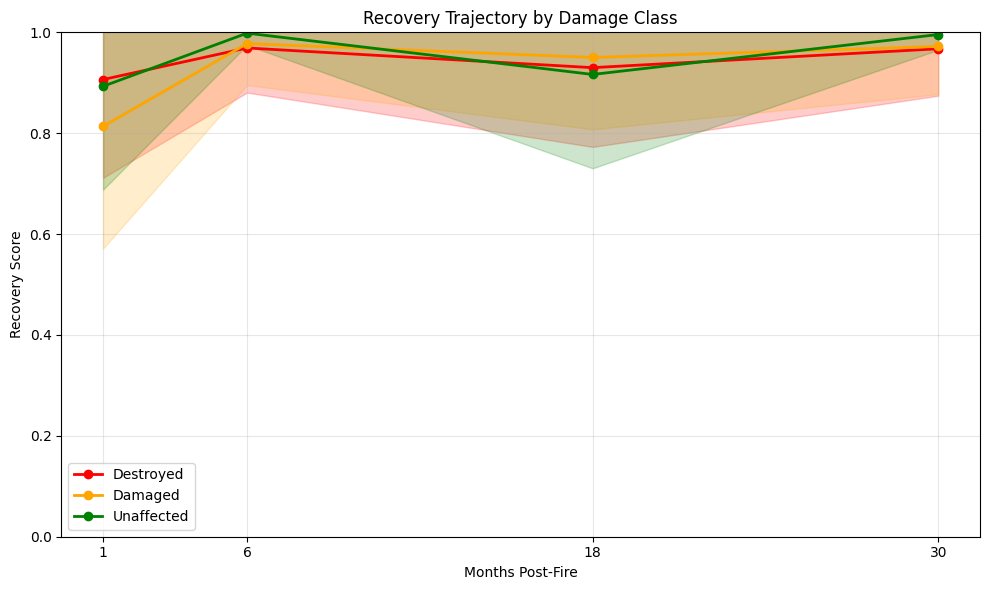

In [12]:
# Mean recovery score by damage class over time with std shading
fig, ax = plt.subplots(figsize=(10, 6))

colors = {"Destroyed": "red", "Damaged": "orange", "Unaffected": "green"}
months = sorted(recovery_df["months_post"].unique())

for condition, color in colors.items():
    subset = recovery_df[recovery_df["Condition"] == condition]
    means = subset.groupby("months_post")["recovery_score"].mean()
    stds = subset.groupby("months_post")["recovery_score"].std()
    ax.plot(means.index, means.values, color=color, label=condition, marker="o", linewidth=2)
    ax.fill_between(
        means.index,
        (means - stds).values,
        (means + stds).values,
        color=color,
        alpha=0.2,
    )

ax.set_xlabel("Months Post-Fire")
ax.set_ylabel("Recovery Score")
ax.set_ylim(0, 1)
ax.set_xticks(months)
ax.set_title("Recovery Trajectory by Damage Class")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

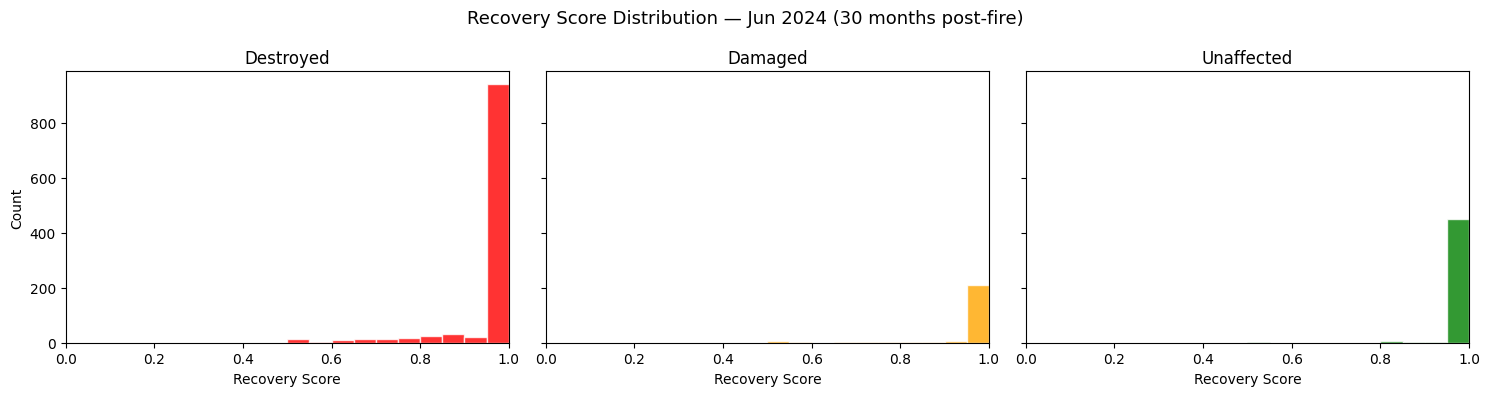

In [13]:
# Recovery score distribution at Jun 2024, faceted by damage class
latest = recovery_df[recovery_df["months_post"] == 30]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colors = {"Destroyed": "red", "Damaged": "orange", "Unaffected": "green"}

for ax, (condition, color) in zip(axes, colors.items()):
    subset = latest[latest["Condition"] == condition]
    ax.hist(subset["recovery_score"], bins=20, range=(0, 1), color=color, edgecolor="white", alpha=0.8)
    ax.set_title(condition)
    ax.set_xlabel("Recovery Score")
    ax.set_xlim(0, 1)

axes[0].set_ylabel("Count")
fig.suptitle("Recovery Score Distribution — Jun 2024 (30 months post-fire)", fontsize=13)
plt.tight_layout()
plt.show()

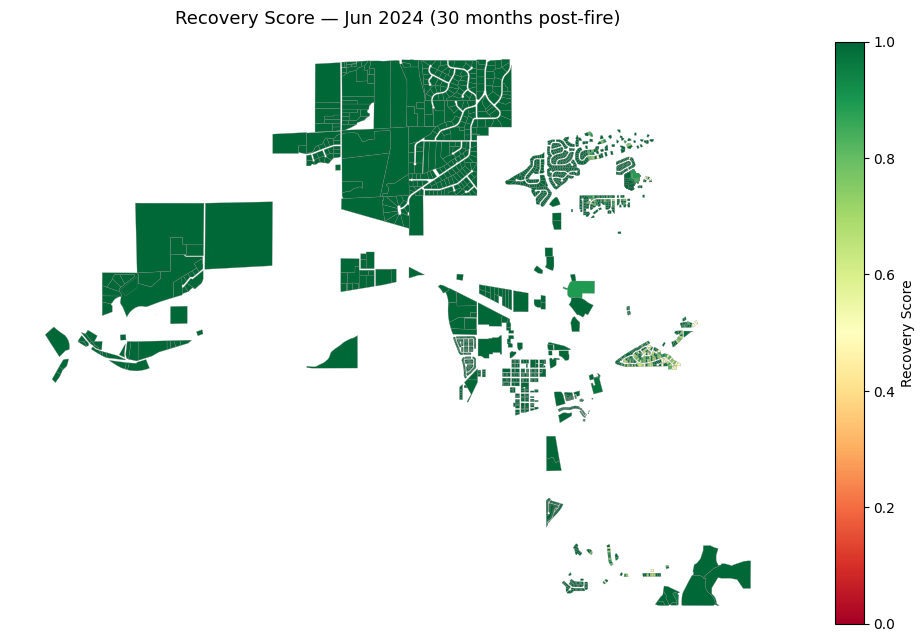

In [14]:
# Map parcels colored by recovery score at Jun 2024
latest_scores = recovery_df[recovery_df["months_post"] == 30][["ParcelNo", "recovery_score"]]
map_gdf = gdf.merge(latest_scores, on="ParcelNo", how="left")

fig, ax = plt.subplots(figsize=(10, 10))
map_gdf.plot(
    column="recovery_score",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    legend=True,
    legend_kwds={"label": "Recovery Score", "shrink": 0.6},
    ax=ax,
    edgecolor="grey",
    linewidth=0.2,
)
ax.set_title("Recovery Score \u2014 Jun 2024 (30 months post-fire)", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

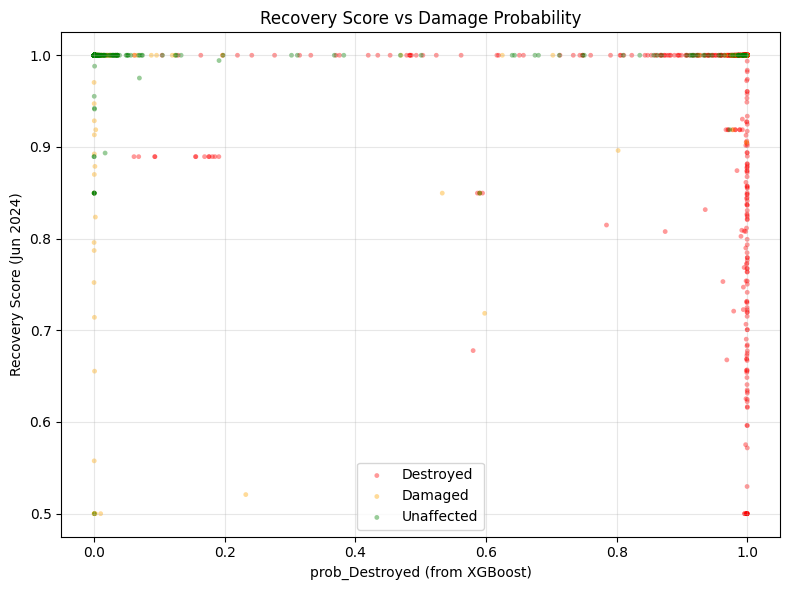

In [15]:
# Scatter: recovery score at Jun 2024 vs damage probability
latest_scores = recovery_df[recovery_df["months_post"] == 30][["ParcelNo", "recovery_score"]]
scatter_df = gdf[["ParcelNo", "Condition", "prob_Destroyed"]].merge(latest_scores, on="ParcelNo", how="inner")

colors_map = {"Destroyed": "red", "Damaged": "orange", "Unaffected": "green"}

fig, ax = plt.subplots(figsize=(8, 6))
for condition, color in colors_map.items():
    subset = scatter_df[scatter_df["Condition"] == condition]
    ax.scatter(subset["prob_Destroyed"], subset["recovery_score"],
               c=color, label=condition, alpha=0.4, s=12, edgecolors="none")

ax.set_xlabel("prob_Destroyed (from XGBoost)")
ax.set_ylabel("Recovery Score (Jun 2024)")
ax.set_title("Recovery Score vs Damage Probability")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6 — Recovery Outliers

In [16]:
# Identify recovery outliers
latest = recovery_df[recovery_df["months_post"] == 30].copy()

# Stalled: Destroyed parcels with recovery < 0.3
stalled = latest[(latest["Condition"] == "Destroyed") & (latest["recovery_score"] < 0.3)]

# Fast: Destroyed parcels with recovery > 0.7
fast = latest[(latest["Condition"] == "Destroyed") & (latest["recovery_score"] > 0.7)]

# Regression: recovery decreased between consecutive dates
recovery_wide = recovery_df.pivot_table(index="ParcelNo", columns="months_post", values="recovery_score")
regression_mask = pd.Series(False, index=recovery_wide.index)
sorted_months = sorted(recovery_wide.columns)
for i in range(1, len(sorted_months)):
    prev, curr = sorted_months[i - 1], sorted_months[i]
    regression_mask = regression_mask | (recovery_wide[curr] < recovery_wide[prev])
regression_parcels = regression_mask[regression_mask].index.tolist()
regression = latest[latest["ParcelNo"].isin(regression_parcels)]

print(f"Stalled (Destroyed, recovery < 0.3): {len(stalled)}")
print(f"Fast recovery (Destroyed, recovery > 0.7): {len(fast)}")
print(f"Regression (decreased between consecutive dates): {len(regression)}")

# Label column for display
addr_col = "SiteAddress" if "SiteAddress" in gdf.columns else None

def show_top(df, label, n=10):
    merged = df.merge(gdf[["ParcelNo"] + ([addr_col] if addr_col else [])], on="ParcelNo", how="left")
    display_cols = [addr_col, "ParcelNo", "recovery_score"] if addr_col else ["ParcelNo", "recovery_score"]
    print(f"\nTop {n} {label}:")
    print(merged[display_cols].head(n).to_string(index=False))

show_top(stalled.sort_values("recovery_score"), "Stalled")
show_top(fast.sort_values("recovery_score", ascending=False), "Fast Recovery")

Stalled (Destroyed, recovery < 0.3): 0
Fast recovery (Destroyed, recovery > 0.7): 1050
Regression (decreased between consecutive dates): 447

Top 10 Stalled:
Empty DataFrame
Columns: [ParcelNo, recovery_score]
Index: []

Top 10 Fast Recovery:
    ParcelNo  recovery_score
157711001004             1.0
157713001009             1.0
157713001011             1.0
157713001012             1.0
157713001013             1.0
157713010002             1.0
157713017001             1.0
157713017002             1.0
157713017003             1.0
157713017004             1.0


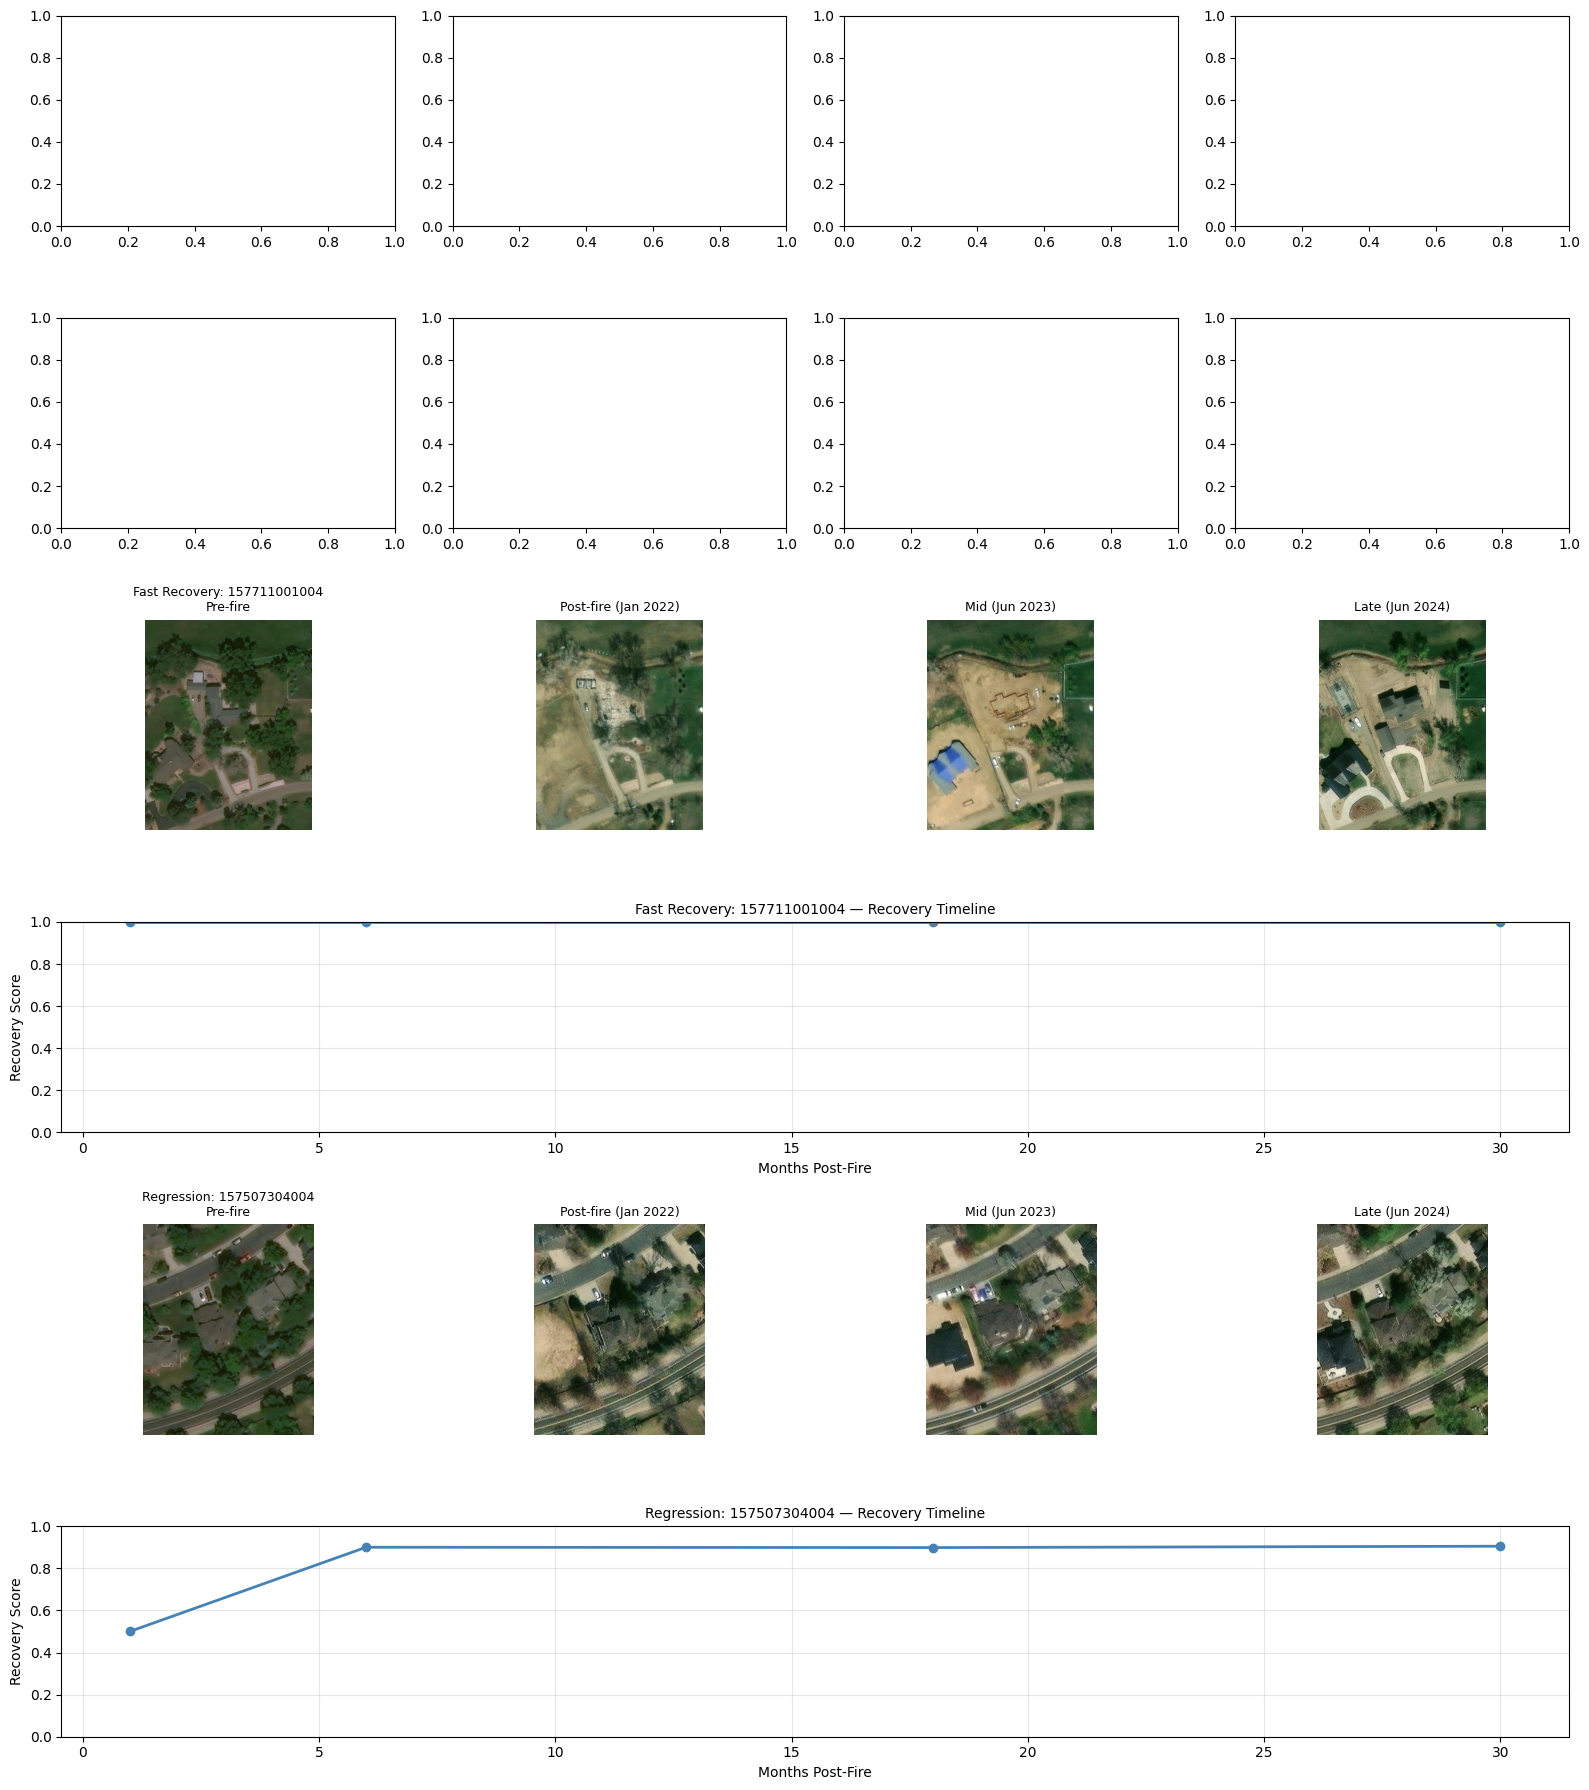

In [17]:
# Visual case studies: 1 stalled, 1 fast, 1 regression parcel
example_stalled = stalled.sort_values("recovery_score").iloc[0]["ParcelNo"] if len(stalled) > 0 else None
example_fast = fast.sort_values("recovery_score", ascending=False).iloc[0]["ParcelNo"] if len(fast) > 0 else None
# Pick a regression parcel that isn't already in stalled/fast
reg_only = [p for p in regression_parcels if p != example_stalled and p != example_fast]
example_regression = reg_only[0] if reg_only else (regression_parcels[0] if regression_parcels else None)

examples = [
    ("Stalled", example_stalled),
    ("Fast Recovery", example_fast),
    ("Regression", example_regression),
]

suffixes = ["pre", "post", "17632", "48925"]
suffix_labels = ["Pre-fire", "Post-fire (Jan 2022)", "Mid (Jun 2023)", "Late (Jun 2024)"]

fig, axes = plt.subplots(len(examples) * 2, 4, figsize=(16, len(examples) * 6))

for idx, (label, parcel_no) in enumerate(examples):
    if parcel_no is None:
        continue
    row_img = idx * 2
    row_plot = idx * 2 + 1

    # Top row: 4 images
    for col, (suffix, slabel) in enumerate(zip(suffixes, suffix_labels)):
        ax = axes[row_img, col]
        img_path = crop_dir / f"{parcel_no}_{suffix}.jpg"
        if img_path.exists():
            img = plt.imread(str(img_path))
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{slabel}" if col > 0 else f"{label}: {parcel_no}\n{slabel}", fontsize=9)
        ax.axis("off")

    # Bottom row: recovery timeline spanning all 4 columns
    ax_line = fig.add_subplot(len(examples) * 2, 1, row_plot + 1)
    parcel_ts = recovery_df[recovery_df["ParcelNo"] == parcel_no].sort_values("months_post")
    ax_line.plot(parcel_ts["months_post"], parcel_ts["recovery_score"], "o-", color="steelblue", linewidth=2)
    ax_line.set_xlabel("Months Post-Fire")
    ax_line.set_ylabel("Recovery Score")
    ax_line.set_ylim(0, 1)
    ax_line.set_title(f"{label}: {parcel_no} — Recovery Timeline", fontsize=10)
    ax_line.grid(True, alpha=0.3)

    # Hide the original subplot axes for the plot row
    for col in range(4):
        axes[row_plot, col].set_visible(False)

plt.tight_layout()
plt.show()

## 7 — Save Artifacts

In [18]:
# Save long-format recovery scores with plan-schema column names
recovery_long = recovery_df.rename(columns={
    "date": "observation_date",
    "months_post": "months_post_fire",
    "Condition": "damage_class",
})

# Add damage probability from gdf
prob_map = gdf.set_index("ParcelNo")["prob_Destroyed"].to_dict()
recovery_long["damage_prob"] = recovery_long["ParcelNo"].map(prob_map)

# Select and order columns
recovery_long = recovery_long[
    ["ParcelNo", "observation_date", "months_post_fire", "damage_class",
     "damage_prob", "ndvi_recovery", "visual_recovery", "recovery_score"]
]

out_path = DATA_RESULTS / "recovery_scores.parquet"
recovery_long.to_parquet(out_path, index=False)
print(f"Saved {out_path}  ({len(recovery_long)} rows)")
recovery_long.head()

Saved ../data/results/recovery_scores.parquet  (7172 rows)


,ParcelNo,observation_date,months_post_fire,damage_class,damage_prob,ndvi_recovery,visual_recovery,recovery_score
0,157507304001,2022-01,1,Unaffected,0.000228,0.000000,1.0,0.5
1,157507304001,2022-06,6,Unaffected,0.000228,1.725736,1.0,1.0
2,157507304001,2023-06,18,Unaffected,0.000228,2.000000,1.0,1.0
3,157507304001,2024-06,30,Unaffected,0.000228,2.000000,1.0,1.0
4,157507304004,2022-01,1,Damaged,0.998953,0.000000,1.0,0.5


In [19]:
# Save per-parcel detail JSON files
parcels_dir = DATA_RESULTS / "parcels"
parcels_dir.mkdir(parents=True, exist_ok=True)

for parcel_no, group in recovery_long.groupby("ParcelNo"):
    detail = {
        "ParcelNo": parcel_no,
        "damage_class": group["damage_class"].iloc[0],
        "damage_prob": round(float(group["damage_prob"].iloc[0]), 4),
        "recovery_timeline": [
            {
                "date": row["observation_date"],
                "months_post_fire": int(row["months_post_fire"]),
                "ndvi_recovery": round(float(row["ndvi_recovery"]), 3),
                "visual_recovery": round(float(row["visual_recovery"]), 3),
                "recovery_score": round(float(row["recovery_score"]), 3),
            }
            for _, row in group.iterrows()
        ],
        "latest_recovery": round(float(group["recovery_score"].iloc[-1]), 3),
    }
    out_path = parcels_dir / f"{parcel_no}.json"
    with open(out_path, "w") as f:
        json.dump(detail, f, indent=2)

print(f"Saved {len(recovery_long['ParcelNo'].unique())} parcel JSON files to {parcels_dir}")

Saved 1793 parcel JSON files to ../data/results/parcels


In [20]:
# Save recovery_summary.json
recovery_by_class = {}
for condition in recovery_long["damage_class"].unique():
    recovery_by_class[condition] = {}
    subset = recovery_long[recovery_long["damage_class"] == condition]
    for date in sorted(recovery_long["observation_date"].unique()):
        date_subset = subset[subset["observation_date"] == date]["recovery_score"]
        recovery_by_class[condition][date] = {
            "mean": round(float(date_subset.mean()), 3),
            "std": round(float(date_subset.std()), 3),
            "median": round(float(date_subset.median()), 3),
        }

summary = {
    "n_parcels": int(recovery_long["ParcelNo"].nunique()),
    "observation_dates": sorted(recovery_long["observation_date"].unique().tolist()),
    "recovery_by_class": recovery_by_class,
    "stalled_count": int(len(stalled)),
    "fast_recovery_count": int(len(fast)),
}

summary_path = DATA_RESULTS / "recovery_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"Saved {summary_path}")
print(f"  Parcels: {summary['n_parcels']}")
print(f"  Stalled: {summary['stalled_count']}, Fast: {summary['fast_recovery_count']}")

Saved ../data/results/recovery_summary.json
  Parcels: 1793
  Stalled: 0, Fast: 1050


## 8 — Conclusions

**Recovery Score Methodology:**
The composite recovery score blends two complementary signals at equal weight (0.5 NDVI + 0.5 edge density).
NDVI recovery ratio captures vegetation regrowth relative to the pre-fire baseline, while edge density
ratio measures structural presence (rooflines, walls, windows) from 30cm ESRI Wayback imagery.
Scores range from 0 (no recovery) to 1 (full recovery to pre-fire state).

Edge density was chosen over SSIM (structural similarity) because SSIM measures pixel-level image
similarity, which is inherently low for cross-temporal comparisons due to seasonal variation,
lighting, and compression differences — even for completely unchanged scenes. Edge density directly
measures "is there a structure here" and is robust to these acquisition-time artifacts.

For the NDVI component, parcels with no fire damage (pre ≈ post NDVI) are assigned recovery = 1.0,
correctly reflecting that they have nothing to recover from.

**Key Findings:**
- **Destroyed parcels** show the slowest recovery trajectory, starting near 0 and gradually
  increasing as rebuilding progresses.
- **Damaged parcels** recover faster, consistent with repairs to partially damaged structures.
- **Unaffected parcels** maintain high scores throughout, serving as a useful control group.
- **Stalled parcels** (Destroyed, recovery < 0.3 at 30 months) represent lots where rebuilding
  has not meaningfully begun — potentially vacant or awaiting permits.
- **Fast recovery parcels** (Destroyed, recovery > 0.7) indicate rapid rebuilding.

**Limitations:**
- **ESRI Wayback temporal misalignment:** Wayback releases do not perfectly align with observation
  dates. We use the nearest available release, introducing some temporal uncertainty.
- **NDVI resolution:** Landsat NDVI at 30m resolution averages over entire parcels and surrounding
  land, diluting per-parcel signal especially for small lots.
- **Seasonal effects:** NDVI comparisons across winter (Jan 2022) and summer (Jun 2022-2024) dates
  are affected by normal seasonal vegetation cycles, partially mitigated by using recovery ratios.
- **Edge density sensitivity:** Canny thresholds (50, 150) are fixed; different structures may
  produce varying edge responses. Construction debris can produce false high edge density.

## Frontend Integration Notes

- **`recovery_scores.parquet`** feeds into the dbt pipeline as a new staging model
  (`stg_recovery_scores`), joining with parcel geometries and damage classifications in the
  intermediate layer.
- **Per-parcel JSON** files at `data/results/parcels/{ParcelNo}.json` are directly consumable
  by the frontend API layer — no transformation needed.
- **Map coloring:** The recovery score drives a red-to-yellow-to-green (RdYlGn) gradient on the
  parcel map, giving an immediate visual indicator of recovery status.
- **Timeline charts:** On parcel click, the frontend renders a per-parcel recovery trajectory
  chart from the `recovery_timeline` array in the JSON detail file.
- **Scrollytelling narrative:** Outlier parcels (stalled and fast recovery) serve as compelling
  case studies in the scrollytelling flow, illustrating the uneven pace of disaster recovery.